# Delivery-time linear regression — images 09–12 explained

**Question:** How can we estimate delivery time from distance, and how do we judge the result?



## Setup — libraries and file locations
**Why:** pandas manages tables; NumPy performs the equations; scikit-learn independently fits and scores the model; Matplotlib draws the results. If imports fail, uncomment and run the installation cell, then restart the kernel.

In [1]:
# %pip install numpy pandas matplotlib scikit-learn

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

candidates = [Path.cwd(), *Path.cwd().parents]
candidates += [p / 'Linear-Regression' / 'Delivery-Time' for p in candidates.copy()]
DATA_DIR = next((p for p in candidates if (p / 'deliveries_raw.csv').is_file()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Run from the repository root or Delivery-Time/illustrated_v2 folder.')
OUTPUT_DIR = DATA_DIR / 'illustrated_v2' / 'notebook_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pd.options.display.float_format = '{:,.6f}'.format
print('Input folder:', DATA_DIR)
print('Export folder:', OUTPUT_DIR)

Input folder: C:\manish\ejagruti\genai\myprojects\aiml\Linear-Regression\Delivery-Time
Export folder: C:\manish\ejagruti\genai\myprojects\aiml\Linear-Regression\Delivery-Time\illustrated_v2\notebook_outputs


## Image 10 · Panel 25 — Load and inspect
**What:** Read the source and inspect dimensions, types, missing values and duplicates.

**Why:** A model assumes its inputs represent valid observations. Missing distances cannot be used as predictors, missing times cannot supervise training, and an exact repeated delivery would get extra weight.

**Read the output:** Expect 30 rows, 3 columns, one missing distance, one missing time and one exact duplicate. `delivery_id` tracks a record; it is **not a predictive feature**.

In [3]:
raw = pd.read_csv(DATA_DIR / 'deliveries_raw.csv')
print('Source shape (rows, columns):', raw.shape)
display(raw)
display(raw.dtypes.rename('Data type').to_frame())
display(raw.isna().sum().rename('Missing values').to_frame())
print('Exact duplicate rows:', raw.duplicated().sum())

Source shape (rows, columns): (30, 3)


,delivery_id,distance_km,time_min
0,D01,1.000000,15.000000
1,D02,2.000000,15.000000
2,D03,3.000000,21.000000
3,D04,4.000000,20.000000
4,D05,5.000000,26.000000
5,D06,6.000000,26.000000
6,D07,7.000000,33.000000
7,D08,8.000000,33.000000
8,D09,9.000000,36.000000
9,D10,10.000000,38.000000


,Data type
delivery_id,str
distance_km,float64
time_min,float64


,Missing values
delivery_id,0
distance_km,1
time_min,1


Exact duplicate rows: 1


## Image 10 · Panel 26 — Apply deterministic quality rules
**What:** Remove exact duplicates, convert numeric fields, remove missing values, and require positive distance and time.

**Why:** These are declared validity rules for this exercise. `errors='coerce'` converts unparseable values to missing values so they can be inspected. `.copy()` gives us an independent table. These rules yield **30 → 29 → 27 → 26 rows**. Removing incomplete rows is the teaching choice here; in a real dataset, investigate missingness and possible selection bias.

In [4]:
counts = [('Raw source', len(raw))]
df = raw.drop_duplicates().copy()
counts.append(('After exact duplicates removed', len(df)))
cols = ['distance_km', 'time_min']
for c in cols:
    original = df[c].copy()
    df[c] = pd.to_numeric(df[c], errors='coerce')
    print(f'{c}: new parsing failures = {(original.notna() & df[c].isna()).sum()}')
df = df.dropna(subset=cols)
counts.append(('After missing values removed', len(df)))
valid = df.loc[(df.distance_km > 0) & (df.time_min > 0)].copy()
counts.append(('After positive-value rules', len(valid)))
display(pd.DataFrame(counts, columns=['Cleaning stage', 'Rows']))

distance_km: new parsing failures = 0
time_min: new parsing failures = 0


,Cleaning stage,Rows
0,Raw source,30
1,After exact duplicates removed,29
2,After missing values removed,27
3,After positive-value rules,26


## Image 10 · Panel 27 — Flag, audit, then clean
**What:** Calculate the interquartile range (IQR = Q3 − Q1) and flag times outside Q1 − 1.5×IQR and Q3 + 1.5×IQR.

**Why:** A flag invites investigation; it does not establish that a record is wrong. The supplied synthetic audit says D29's timer continued after delivery, so we exclude D29. D25's 99-minute traffic delay is valid, so we retain it. The full-data IQR is **descriptive only** and does not decide which test rows survive.

**Read the output:** Q1 = 33, Q3 = 66.75, IQR = 33.75, fences = −17.625 and 117.375. D29 is flagged; 25 cleaned rows remain. The negative lower fence is a statistical threshold, not a valid delivery time.

In [5]:
q1, q3 = valid.time_min.quantile([.25, .75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flag = (valid.time_min < lo) | (valid.time_min > hi)
display(pd.Series({'Q1': q1, 'Q3': q3, 'IQR': iqr,
                   'Lower fence': lo, 'Upper fence': hi}).to_frame('Minutes'))
print('Flagged rows — investigate before excluding:')
display(valid.loc[flag])
print('Provided teaching audit:')
display(pd.read_csv(DATA_DIR / 'cleaning_audit.csv'))
clean = valid.loc[valid.delivery_id != 'D29'].copy().reset_index(drop=True)
print('Clean rows:', len(clean))
display(clean)
assert len(clean) == 25 and 'D25' in clean.delivery_id.values

,Minutes
Q1,33.000000
Q3,66.750000
IQR,33.750000
Lower fence,-17.625000
Upper fence,117.375000


Flagged rows — investigate before excluding:


,delivery_id,distance_km,time_min
28,D29,10.000000,180.000000


Provided teaching audit:


,record,action,reason
0,D05 (row 30),Remove duplicate,"Exact repeat of row 5; same delivery, not anot..."
1,D26,Exclude missing predictor,Distance unavailable in source; do not invent ...
2,D27,Exclude missing target,Actual time unavailable; cannot supervise trai...
3,D28,Exclude invalid value,Negative route distance; source cannot recover...
4,D29,Remove confirmed error,Synthetic audit: timer continued after complet...
5,D25,Retain genuine delay,Synthetic audit: traffic delay; valid 99-minut...


Clean rows: 25


,delivery_id,distance_km,time_min
0,D01,1.000000,15.000000
1,D02,2.000000,15.000000
2,D03,3.000000,21.000000
3,D04,4.000000,20.000000
4,D05,5.000000,26.000000
5,D06,6.000000,26.000000
6,D07,7.000000,33.000000
7,D08,8.000000,33.000000
8,D09,9.000000,36.000000
9,D10,10.000000,38.000000


## Image 10 · Visual check — Box plot before and after the audit
**Why we do this:** A box plot summarizes the distribution of delivery times and makes unusually high or low values easy to spot. Comparing the 26 valid rows with the 25 audited rows shows what changed when the confirmed timer error was removed.

**How to read it:** The box spans Q1 to Q3 (the middle 50% of times), the line inside is the median, and the whiskers end at the most extreme observations within 1.5 × IQR of the box. Separate circles are statistical outlier flags, not automatic deletion instructions. Each box computes its own quartiles. D29 is a confirmed error; D25 is a genuine delay and stays in the data even if a plot flags it.

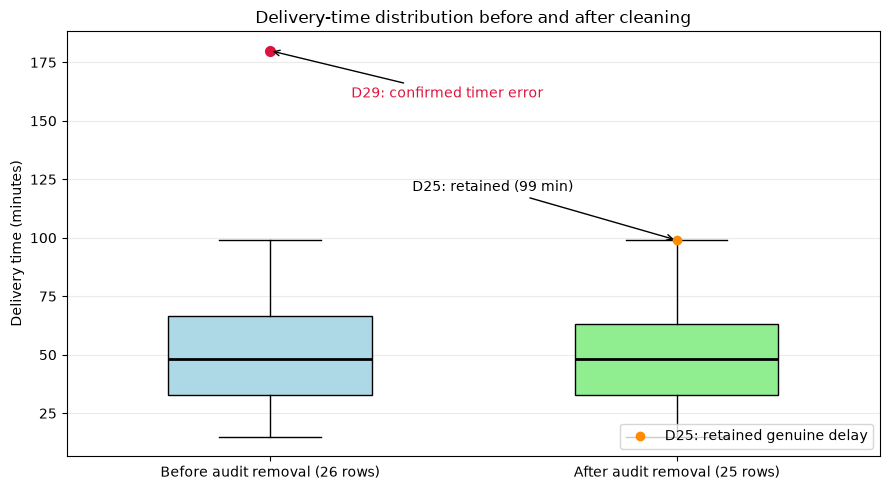

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
boxes = ax.boxplot([valid.time_min.to_numpy(), clean.time_min.to_numpy()],
                  positions=[1, 2], widths=.5, patch_artist=True,
                  medianprops={'color': 'black', 'linewidth': 2},
                  flierprops={'marker': 'o', 'markerfacecolor': 'crimson',
                              'markeredgecolor': 'crimson', 'markersize': 7})
for patch, color in zip(boxes['boxes'], ['lightblue', 'lightgreen']):
    patch.set_facecolor(color)
ax.set_xticks([1, 2], ['Before audit removal (26 rows)', 'After audit removal (25 rows)'])
ax.set(title='Delivery-time distribution before and after cleaning',
       ylabel='Delivery time (minutes)')
ax.annotate('D29: confirmed timer error',
            xy=(1, valid.loc[valid.delivery_id.eq('D29'), 'time_min'].iloc[0]),
            xytext=(1.2, 160), arrowprops={'arrowstyle': '->'}, color='crimson')
ax.scatter([2], [99], color='darkorange', zorder=3, label='D25: retained genuine delay')
ax.annotate('D25: retained (99 min)', xy=(2, 99), xytext=(1.35, 120),
            arrowprops={'arrowstyle': '->'})
ax.grid(axis='y', alpha=.25)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'delivery_time_box_plot.png', dpi=160, bbox_inches='tight')
plt.show()

## Image 10 · Visual check — Scatter plot of distance and delivery time
**Why we do this:** Before fitting a line, examine whether time generally rises with distance and whether a straight-line relationship looks plausible. Each point is one delivery; its horizontal position is distance and its vertical position is actual delivery time.

**How to read it:** The cleaned observations show an upward trend. D25 is highlighted because a genuine delay may sit above the overall pattern. The second panel shows how D29's timer error stands apart from the valid relationship. A scatter plot reveals associations; it does not establish causation. The fitted-line and residual plots appear later after we train the model.

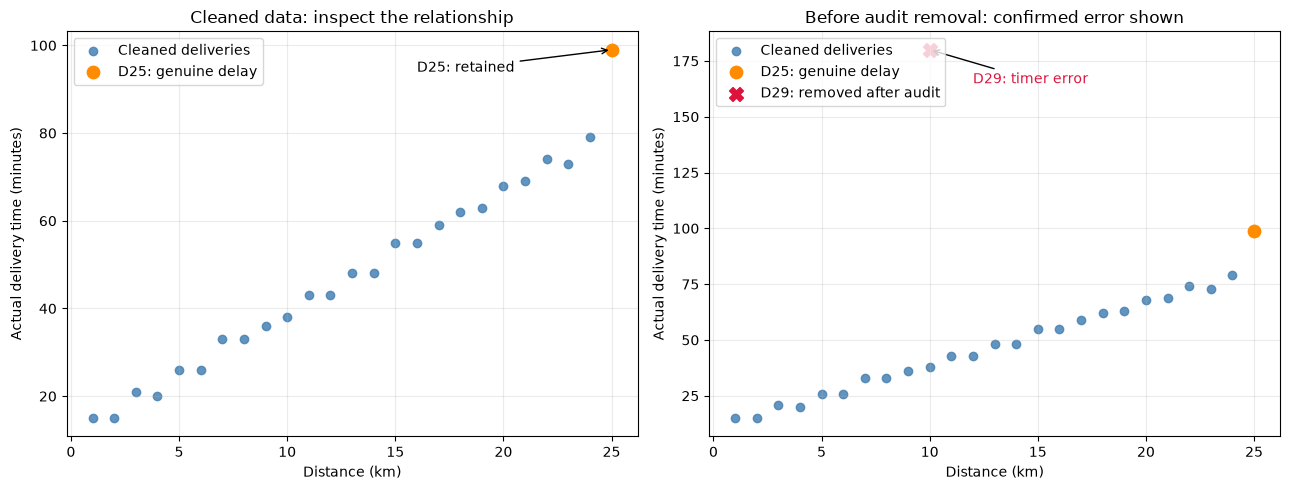

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax in axes:
    ax.scatter(clean.distance_km, clean.time_min, color='steelblue',
               label='Cleaned deliveries', alpha=.85)
    delayed = clean.loc[clean.delivery_id.eq('D25')]
    ax.scatter(delayed.distance_km, delayed.time_min, color='darkorange',
               s=80, label='D25: genuine delay', zorder=3)
    ax.set(xlabel='Distance (km)', ylabel='Actual delivery time (minutes)')
    ax.grid(alpha=.25)
axes[0].set_title('Cleaned data: inspect the relationship')
axes[0].annotate('D25: retained', xy=(25, 99), xytext=(16, 94),
                 arrowprops={'arrowstyle': '->'})
timer_error = valid.loc[valid.delivery_id.eq('D29')]
axes[1].scatter(timer_error.distance_km, timer_error.time_min, marker='X',
                s=100, color='crimson', label='D29: removed after audit')
axes[1].annotate('D29: timer error', xy=(10, 180), xytext=(12, 165),
                 arrowprops={'arrowstyle': '->'}, color='crimson')
axes[1].set_title('Before audit removal: confirmed error shown')
for ax in axes:
    ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'delivery_time_scatter_plot.png', dpi=160, bbox_inches='tight')
plt.show()

## Image 11 · Panel 28 — Calculate the least-squares line with NumPy
**What:** Fit ŷ = b₀ + b₁x, with distance x in km and predicted time ŷ in minutes.

**Why:** Least squares chooses the slope and intercept that minimize the sum of squared residuals. Centering gives `dx = x − mean(x)` and `dy = y − mean(y)`. Then **b₁ = Σ(dx·dy) / Σ(dx²)** and **b₀ = mean(y) − b₁·mean(x)**. The denominator must be positive: identical distances cannot identify a slope.

**Read the output:** b₀ = 9.51 minutes and b₁ ≈ 2.963846 minutes/km. An extra kilometre is associated with about 2.96 more predicted minutes. The intercept describes the mathematical prediction at zero km, outside the observed 1–25 km range; it is not a measured fixed preparation time.

In [8]:
x = clean.distance_km.to_numpy()
y = clean.time_min.to_numpy()
dx, dy = x - x.mean(), y - y.mean()
sxx, sxy = np.sum(dx**2), np.sum(dx * dy)
assert sxx > 0, 'Distance must vary to estimate a slope.'
b1 = sxy / sxx
b0 = y.mean() - b1 * x.mean()
pred = b0 + b1 * x
e = y - pred
sse = np.sum(e**2)
sst = np.sum((y - y.mean())**2)
mse, r2 = sse / len(y), 1 - sse / sst
rmse = np.sqrt(mse)
display(pd.Series({'Mean distance (km)': x.mean(), 'Mean time (min)': y.mean(),
                   'Sxx': sxx, 'Sxy': sxy, 'Intercept (min)': b0,
                   'Slope (min/km)': b1}).to_frame('Value'))
print(f'Fitted equation: predicted minutes = {b0:.6f} + {b1:.6f} × distance_km')

,Value
Mean distance (km),13.000000
Mean time (min),48.040000
Sxx,"1,300.000000"
Sxy,"3,853.000000"
Intercept (min),9.510000
Slope (min/km),2.963846


Fitted equation: predicted minutes = 9.510000 + 2.963846 × distance_km


## Image 11 · Panel 29 — Fit with scikit-learn and predict 12.5 km
**Why:** Repeating the calculation using a library checks that our hand-derived implementation is correct. Double brackets make `X` a two-dimensional feature table: **25 rows × 1 feature**. `y` is the one-dimensional target. The assertions compare floating-point values with a tolerance.

The new delivery uses the same feature name and units. At 12.5 km the full-data model predicts approximately **46.558077 minutes**. This is a point estimate, not a guaranteed arrival time.

In [9]:
X = clean[['distance_km']]
model = LinearRegression().fit(X, y)
assert np.allclose(model.coef_[0], b1)
assert np.allclose(model.intercept_, b0)
assert np.allclose(model.predict(X), pred)
assert np.isclose(mean_squared_error(y, pred), mse)
assert np.isclose(r2_score(y, pred), r2)
print('Feature shape:', X.shape)
print('Manual and library coefficients, predictions and metrics agree.')
new = pd.DataFrame({'distance_km': [12.5]})
display(new.assign(predicted_time_min=model.predict(new)))

Feature shape: (25, 1)
Manual and library coefficients, predictions and metrics agree.


,distance_km,predicted_time_min
0,12.500000,46.558077


## Image 11 · Panel 30 — Export every calculation
**Why:** A row-by-row calculation table lets us trace the equations back to individual deliveries and review unusually large errors. Residual **e = actual − predicted**: positive means the delivery took longer than predicted. Squaring prevents positive and negative errors from cancelling.

`dx`, `dy`, `dx_squared`, and `dx_dy` reproduce the slope calculation; `residual_squared` sums to SSE; `target_deviation_squared` sums to SST. `index=False` avoids writing an extra index column to CSV.

In [10]:
work = clean.assign(dx=dx, dy=dy, dx_squared=dx**2, dx_dy=dx*dy,
                    prediction=pred, residual=e, residual_squared=e**2,
                    target_deviation_squared=dy**2)
work.to_csv(OUTPUT_DIR / 'python_calculations.csv', index=False)
display(work)
print('Saved:', OUTPUT_DIR / 'python_calculations.csv')

,delivery_id,distance_km,time_min,dx,dy,dx_squared,dx_dy,prediction,residual,residual_squared,target_deviation_squared
0,D01,1.000000,15.000000,-12.000000,-33.040000,144.000000,396.480000,12.473846,2.526154,6.381453,"1,091.641600"
1,D02,2.000000,15.000000,-11.000000,-33.040000,121.000000,363.440000,15.437692,-0.437692,0.191575,"1,091.641600"
2,D03,3.000000,21.000000,-10.000000,-27.040000,100.000000,270.400000,18.401538,2.598462,6.752002,731.161600
3,D04,4.000000,20.000000,-9.000000,-28.040000,81.000000,252.360000,21.365385,-1.365385,1.864275,786.241600
4,D05,5.000000,26.000000,-8.000000,-22.040000,64.000000,176.320000,24.329231,1.670769,2.791470,485.761600
5,D06,6.000000,26.000000,-7.000000,-22.040000,49.000000,154.280000,27.293077,-1.293077,1.672048,485.761600
6,D07,7.000000,33.000000,-6.000000,-15.040000,36.000000,90.240000,30.256923,2.743077,7.524471,226.201600
7,D08,8.000000,33.000000,-5.000000,-15.040000,25.000000,75.200000,33.220769,-0.220769,0.048739,226.201600
8,D09,9.000000,36.000000,-4.000000,-12.040000,16.000000,48.160000,36.184615,-0.184615,0.034083,144.961600
9,D10,10.000000,38.000000,-3.000000,-10.040000,9.000000,30.120000,39.148462,-1.148462,1.318964,100.801600


Saved: C:\manish\ejagruti\genai\myprojects\aiml\Linear-Regression\Delivery-Time\illustrated_v2\notebook_outputs\python_calculations.csv


## Image 09 · Panels 21–24 — Explain SSE, MSE, RMSE and R²

| Label | Calculation | Why we use it / interpretation |
|---|---|---|
| 21 · SSE | Σe² | Total squared error; large misses contribute strongly. Units: min². |
| 21 · MSE | SSE / n | Average squared error per observation. Units: min². |
| 22 · RMSE | √MSE | Error magnitude in minutes; **not** a maximum error or confidence interval. |
| 23 · Mean-only baseline | Predict mean(y); SST = Σ(y − mean(y))² | Reference model that ignores distance. |
| 24 · R² | 1 − SSE/SST | Reduction in squared error relative to the mean-only reference on these rows. |

These are **in-sample metrics for the model fitted on all 25 cleaned rows**. R² ≈ 0.972141 means about 97.21% of this sample's target variation is explained relative to its mean-only reference. It does **not** mean 97.21% prediction accuracy. MSE here divides by n; the usual residual-variance estimate for a line with two fitted parameters divides by n − 2.

In [11]:
baseline = np.full(y.shape, y.mean())
display(pd.DataFrame([
    ['Full-data fitted line', len(y), sse, mse, rmse, r2],
    ['Mean-only baseline', len(y), sst, np.mean((y-baseline)**2),
     np.sqrt(np.mean((y-baseline)**2)), r2_score(y, baseline)]
], columns=['Model evaluated on its fitting data', 'Rows', 'SSE (min²)',
            'MSE (min²)', 'RMSE (min)', 'R²']))
print(f'Residual variance estimate SSE/(n−2): {sse / (len(y)-2):.6f} min²')
assert np.allclose([sse, mse, rmse, r2],
                   [327.260769, 13.090431, 3.618070, .972141], atol=1e-6)

,Model evaluated on its fitting data,Rows,SSE (min²),MSE (min²),RMSE (min),R²
0,Full-data fitted line,25,327.260769,13.090431,3.618070,0.972141
1,Mean-only baseline,25,"11,746.960000",469.878400,21.676679,0.000000


Residual variance estimate SSE/(n−2): 14.228729 min²


## Image 11 · Panel 31 and Image 09 · Panel 25 — Plot fit and residuals
**Why:** A good single score can hide systematic mistakes. The left plot shows the distance–time relationship; sorting x ensures the fitted line is drawn in distance order. The right plot compares residuals with fitted times and includes a zero-error reference.

Look for curves (a straight line may miss structure), changing spread (error variability may depend on distance), and unusual cases. D25 has a large positive residual of about 15.39 minutes but remains because its delay is valid. A plot alone cannot establish independence or prove all model assumptions.

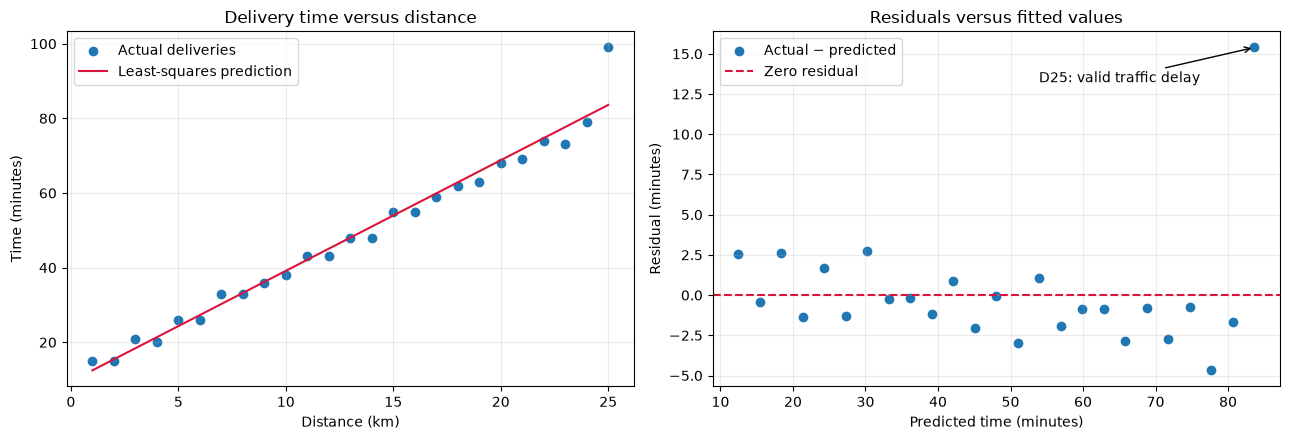

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
order = np.argsort(x)
ax[0].scatter(x, y, label='Actual deliveries')
ax[0].plot(x[order], pred[order], color='crimson', label='Least-squares prediction')
ax[0].set(title='Delivery time versus distance', xlabel='Distance (km)', ylabel='Time (minutes)')
ax[1].scatter(pred, e, label='Actual − predicted')
ax[1].axhline(0, color='crimson', linestyle='--', label='Zero residual')
ax[1].set(title='Residuals versus fitted values', xlabel='Predicted time (minutes)',
          ylabel='Residual (minutes)')
i = clean.index[clean.delivery_id.eq('D25')][0]
ax[1].annotate('D25: valid traffic delay', xy=(pred[i], e[i]),
               xytext=(-155, -25), textcoords='offset points',
               arrowprops={'arrowstyle': '->'})
for axis in ax:
    axis.legend()
    axis.grid(alpha=.25)
fig.tight_layout()
plt.show()

## Image 09 · Panels 26–28 — Assumptions and business limits
**Why:** Numerical agreement verifies the calculation, not that the model is suitable for every delivery.

- **Linear conditional mean:** the average time at a given distance should be reasonably represented by a line.
- **Independence:** shared routes, drivers or consecutive deliveries may create dependence; investigate ordering and operational context.
- **Constant variance:** matters for the usual uncertainty formulas. Unequal variance does not prevent computing the least-squares fit.
- **Normal errors:** used for exact small-sample inference under the classical assumptions; not required to compute OLS coefficients.
- **Scope:** these 25-row scores describe the fitting sample. Distance alone does not establish causation. Avoid extrapolating beyond 1–25 km; traffic and time-of-day may improve a future model.

Next, we train a **separate** model to evaluate deliveries it did not see during fitting.

## Image 12 · Panel 32 — Split, refit and predict unseen rows
**What:** Use 80% of the 25 cleaned rows for training and 20% for testing: **20 training / 5 test**. `random_state=42` reproduces the poster's split; it does not improve model quality.

**Why:** Scoring a model on its fitting data can be optimistic. We fit a new `held` model on training rows only, then predict test rows. Reusing `model`, which saw all 25 rows, would leak test information. Different training rows produce different coefficients.

In [13]:
train, test = train_test_split(clean, test_size=0.2, random_state=42)
held = LinearRegression().fit(train[['distance_km']], train.time_min)
hp = held.predict(test[['distance_km']])
he = test.time_min.to_numpy() - hp
print(f'Training rows: {len(train)}; test rows: {len(test)}')
print('Test delivery IDs:', test.delivery_id.tolist())
print(f'New equation: predicted minutes = {held.intercept_:.6f} + '
      f'{held.coef_[0]:.6f} × distance_km')
assert set(train.delivery_id).isdisjoint(test.delivery_id)

Training rows: 20; test rows: 5
Test delivery IDs: ['D09', 'D17', 'D01', 'D24', 'D12']
New equation: predicted minutes = 8.983929 + 3.012677 × distance_km


## Image 12 · Panel 33 — Show all five test errors
**Why:** A five-row test set is small enough to inspect in full. Compare actual and predicted minutes, the signed residual and its square. Positive residuals are underpredictions; negative residuals are overpredictions. Keep valid difficult cases in evaluation.

In [14]:
comparison = test[['delivery_id', 'distance_km', 'time_min']].copy()
comparison['prediction'] = hp
comparison['error'] = he
comparison['error_squared'] = he**2
display(comparison.reset_index(drop=True))
comparison.to_csv(OUTPUT_DIR / 'python_holdout.csv', index=False)

,delivery_id,distance_km,time_min,prediction,error,error_squared
0,D09,9.000000,36.000000,36.098024,-0.098024,0.009609
1,D17,17.000000,59.000000,60.199441,-1.199441,1.438659
2,D01,1.000000,15.000000,11.996606,3.003394,9.020375
3,D24,24.000000,79.000000,81.288181,-2.288181,5.235774
4,D12,12.000000,43.000000,45.136055,-2.136055,4.562731


## Image 12 · Panel 34 — Report held-out metrics
**Why:** These errors estimate performance on rows excluded from this model's training. The poster's test R² uses the **test mean** to define test SST, as `r2_score` does. That reference is a scoring convention, not a deployable prediction learned from training.

For an operational baseline, also predict the **training mean** for every test row. We compare its RMSE below. Expected model test RMSE ≈ **2.013313 min**, test R² ≈ **0.991291**. A lower test RMSE than the full-data training RMSE is possible with this small, different sample; it does not prove the new model is better. Held-out R² can be negative when predictions are worse than its mean reference.

In [15]:
test_sse = np.sum(he**2)
test_sst = np.sum((test.time_min - test.time_min.mean())**2)
test_mse = test_sse / len(test)
test_rmse = np.sqrt(test_mse)
test_r2 = 1 - test_sse / test_sst
display(pd.Series({'Test SSE (min²)': test_sse, 'Test MSE (min²)': test_mse,
                   'Test RMSE (min)': test_rmse, 'Test mean (min)': test.time_min.mean(),
                   'Test SST (min²)': test_sst, 'Test R²': test_r2}).to_frame('Value'))
baseline_test = np.full(len(test), train.time_min.mean())
display(pd.DataFrame({
    'Prediction rule': ['Line fitted on 20 training rows', 'Mean of 20 training times'],
    'Test RMSE (min)': [test_rmse, np.sqrt(mean_squared_error(test.time_min, baseline_test))]
}))
assert np.isclose(mean_squared_error(test.time_min, hp), test_mse)
assert np.isclose(r2_score(test.time_min, hp), test_r2)
assert np.allclose([test_sse, test_rmse, test_r2],
                   [20.267147, 2.013313, .991291], atol=1e-6)
assert test.delivery_id.tolist() == ['D09', 'D17', 'D01', 'D24', 'D12']
print('Held-out calculations reproduce the poster values within rounding tolerance.')

,Value
Test SSE (min²),20.267147
Test MSE (min²),4.053429
Test RMSE (min),2.013313
Test mean (min),46.400000
Test SST (min²),"2,327.200000"
Test R²,0.991291


,Prediction rule,Test RMSE (min)
0,Line fitted on 20 training rows,2.013313
1,Mean of 20 training times,21.671237


Held-out calculations reproduce the poster values within rounding tolerance.


## Image 12 · Panels 35–37 — Prevent leakage and decide what comes next

**35 — Prevent leakage:** Deduplicate identities and apply predeclared quality rules. Any learned imputation values, scaling parameters or statistical thresholds must be fitted using training data only. Do not choose model settings by repeatedly inspecting this five-row test set.

**36 — Our IQR was descriptive:** We computed it to illustrate a flag, not to remove test cases. D29 was excluded because of the supplied independent audit. D25 remained. Deleting valid test rows because their residuals are large would make the reported performance misleading.

**37 — Next business step:** Collect more deliveries and evaluate future periods, with route-aware or time-based splits when appropriate. Compare meaningful baselines, monitor changes in errors, and consider traffic/time-of-day features. Five test observations produce an unstable estimate; neither R² nor RMSE guarantees an arrival time.

### What you have produced
You have an auditable 25-row fit, an independently verified calculation, labelled fit/residual charts, a 12.5-km prediction, and a separate 20/5 held-out exercise. The two CSV exports in `notebook_outputs/` preserve all full-data calculations and all five test errors.